# Automatic Multi-Band Dispersion Overlay (Top 3 Bands)

This notebook automatically:
1. detects passbands from DOS,
2. extracts the top 3 bands,
3. plots Band 1 / Band 2 / Band 3 overlays for each MAT file.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path('.').resolve()))

from pinn_dispersion_from_mat import (
    load_pinn_results,
    resample_to_uniform,
    compute_spectrum,
    linear_dispersion,
    compute_dos,
    detect_band_gaps,
    extract_ridge_in_band,
)

In [2]:
# ---------------- USER SETTINGS ----------------
mat_files = [
    '../Result/pinn_data_freq2_A10.mat',
    '../Result/pinn_data_freq2_A15.mat',
    '../Result/pinn_data_freq2_A20.mat',
]

if len(mat_files) == 1 and mat_files[0] == '../Result/pinn_data.mat':
    all_mats = sorted(Path('../Result').glob('*.mat'))
    if len(all_mats) > 1:
        mat_files = [str(p) for p in all_mats]

k_coupling = 1.0      # update to your model
mx = 1.0                # update to your model
n_harmonic = 4
pts_per_cycle = 12
skip_transient = 0.0
omega_min = 0.01
n_bands = 3
force_three_bands = False # True => always split into exactly n_bands windows

# DOS band detection controls
dip_threshold_dB = 50.0
min_distance = 3

print('MAT files to process:')
for f in mat_files:
    print('  -', f)

MAT files to process:
  - ../Result/pinn_data_freq2_A10.mat
  - ../Result/pinn_data_freq2_A15.mat
  - ../Result/pinn_data_freq2_A20.mat


In [3]:
def top_passband_windows(omega_pos, spectrum, n_bands=3, omega_min=0.01,
                        dip_threshold_dB=5.0, min_distance=5, force_n_bands=False):
    """
    Detect passband peaks from DOS and return up to n_bands windows:
    [(w_lo, w_hi), ...], plus selected peak frequencies.
    """
    i0 = np.searchsorted(omega_pos, omega_min)
    omega_clip = omega_pos[i0:]
    spec_clip = spectrum[:, i0:]

    dos, dos_dB = compute_dos(spec_clip)
    gap_freqs, band_freqs = detect_band_gaps(
        omega_clip, dos_dB,
        dip_threshold_dB=dip_threshold_dB,
        min_distance=min_distance
    )

    if len(band_freqs) == 0:
        if force_n_bands:
            edges = np.linspace(omega_clip[0], omega_clip[-1], n_bands + 1)
            windows = [(float(edges[i]), float(edges[i + 1])) for i in range(n_bands)]
            peak_freqs = 0.5 * (edges[:-1] + edges[1:])
            return windows, peak_freqs, omega_clip, dos_dB
        # Fallback: one wide band over full clipped range
        return [(omega_clip[0], omega_clip[-1])], np.array([(omega_clip[0] + omega_clip[-1]) * 0.5]), omega_clip, dos_dB

    # Rank passband peaks by DOS magnitude and keep top n_bands
    band_idx = np.searchsorted(omega_clip, band_freqs)
    band_idx = np.clip(band_idx, 0, len(dos) - 1)
    peak_power = dos[band_idx]
    keep = np.argsort(peak_power)[::-1][:n_bands]
    peak_freqs = np.sort(band_freqs[keep])

    if force_n_bands and len(peak_freqs) < n_bands:
        # Force exactly n_bands by uniform frequency partition (plotting convenience mode).
        edges = np.linspace(omega_clip[0], omega_clip[-1], n_bands + 1)
        windows = [(float(edges[i]), float(edges[i + 1])) for i in range(n_bands)]
        peak_freqs = 0.5 * (edges[:-1] + edges[1:])
        return windows, peak_freqs, omega_clip, dos_dB

    # Build windows by midpoints between selected peaks
    mids = 0.5 * (peak_freqs[:-1] + peak_freqs[1:]) if len(peak_freqs) > 1 else np.array([])

    windows = []
    for i, w0 in enumerate(peak_freqs):
        lo = omega_clip[0] if i == 0 else mids[i - 1]
        hi = omega_clip[-1] if i == len(peak_freqs) - 1 else mids[i]

        # Refine with nearest detected gaps if available
        left_gaps = gap_freqs[gap_freqs < w0]
        right_gaps = gap_freqs[gap_freqs > w0]
        if len(left_gaps) > 0:
            lo = max(lo, left_gaps[-1])
        if len(right_gaps) > 0:
            hi = min(hi, right_gaps[0])

        if hi <= lo:
            # Safety fallback around peak
            bw = max((omega_clip[-1] - omega_clip[0]) / (4 * max(1, len(peak_freqs))), 1e-6)
            lo = max(omega_clip[0], w0 - bw)
            hi = min(omega_clip[-1], w0 + bw)

        windows.append((float(lo), float(hi)))

    return windows, peak_freqs, omega_clip, dos_dB


In [4]:
# Process each MAT file and extract top-n bands
results = []
omega_max_lin = linear_dispersion(np.pi, k_coupling, mx)

for fp in mat_files:
    t_total, x_PINN_total, params = load_pinn_results(fp)
    X_raw = x_PINN_total.T  # (N_time, n_dof) -> (n_dof, M)

    t_u, X_u, dt, omega_nyq = resample_to_uniform(
        t_total, X_raw, omega_max_lin,
        n_harmonic=n_harmonic, pts_per_cycle=pts_per_cycle
    )

    k_pos, omega_pos, spectrum = compute_spectrum(
        t_u, X_u, skip_transient=skip_transient
    )

    windows, peak_freqs, omega_clip, dos_dB = top_passband_windows(
        omega_pos, spectrum,
        n_bands=n_bands,
        omega_min=omega_min,
        dip_threshold_dB=dip_threshold_dB,
        min_distance=min_distance,
        force_n_bands=force_three_bands
    )

    band_curves = []
    for (w_lo, w_hi) in windows:
        i_lo = np.searchsorted(omega_pos, w_lo)
        i_hi = np.searchsorted(omega_pos, w_hi)
        if i_hi <= i_lo + 1:
            band_curves.append(np.full(len(k_pos), np.nan))
            continue

        omega_band = omega_pos[i_lo:i_hi]
        spec_band = spectrum[:, i_lo:i_hi]
        ridge = extract_ridge_in_band(k_pos, omega_band, spec_band, omega_min=omega_band[0])
        band_curves.append(ridge)

    label = Path(fp).stem
    if 'phi2' in params:
        label += f" (phi2={params['phi2']:.3g})"

    results.append({
        'file': fp,
        'label': label,
        'k': k_pos,
        'bands': band_curves,
        'windows': windows,
        'peak_freqs': peak_freqs,
    })

print(f'Processed {len(results)} file(s).')
for r in results:
    print(f"\n{r['label']}")
    for bi, w in enumerate(r['windows'], start=1):
        print(f"  Band {bi}: ω in [{w[0]:.4f}, {w[1]:.4f}]")


Loaded  ../Result/pinn_data_freq2_A10.mat
  t_total      : (50050,),  span 0.000 – 13.740 s
  x_PINN_total : (50050, 20)
  params       : ['n_dof', 'mx', 'my', 'k', 'c', 'D', 'r', 'phi1', 'phi2']
Loaded  ../Result/pinn_data_freq2_A15.mat
  t_total      : (50050,),  span 0.000 – 12.510 s
  x_PINN_total : (50050, 20)
  params       : ['n_dof', 'mx', 'my', 'k', 'c', 'D', 'r', 'phi1', 'phi2']
Loaded  ../Result/pinn_data_freq2_A20.mat
  t_total      : (50050,),  span 0.000 – 11.399 s
  x_PINN_total : (50050, 20)
  params       : ['n_dof', 'mx', 'my', 'k', 'c', 'D', 'r', 'phi1', 'phi2']
Processed 3 file(s).

pinn_data_freq2_A10 (phi2=2)
  Band 1: ω in [0.4571, 7.3143]
  Band 2: ω in [7.3143, 9.1429]
  Band 3: ω in [9.1429, 48.0000]

pinn_data_freq2_A15 (phi2=2)
  Band 1: ω in [0.5000, 6.7500]
  Band 2: ω in [6.7500, 8.5000]
  Band 3: ω in [8.5000, 48.0000]

pinn_data_freq2_A20 (phi2=2)
  Band 1: ω in [0.5486, 8.2286]
  Band 2: ω in [8.2286, 47.7257]


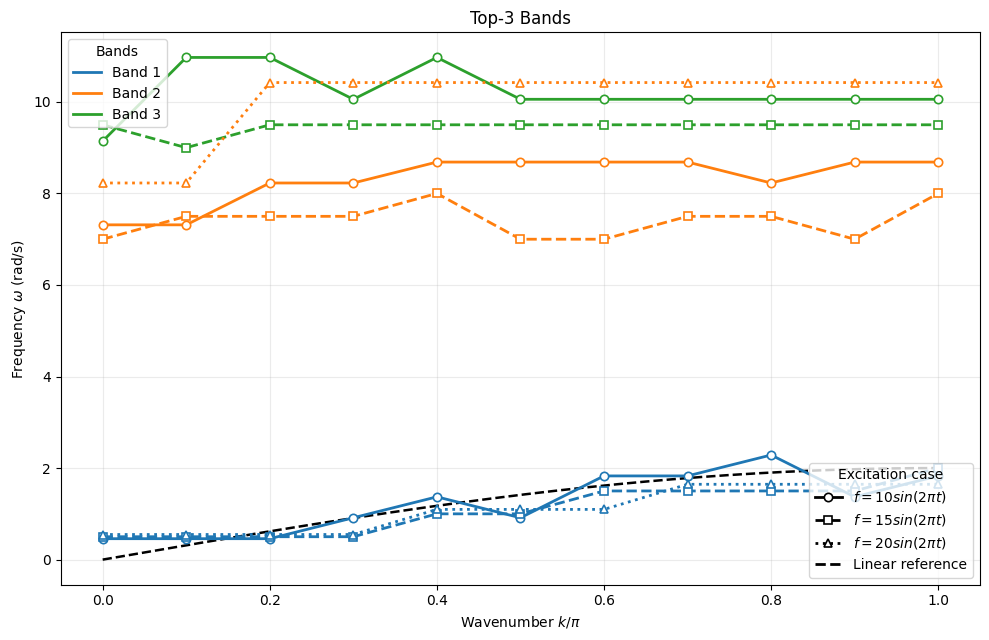

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(10, 6.5))

# -----------------------------
# Style definitions
# -----------------------------
band_colors = {
    1: 'tab:blue',
    2: 'tab:orange',
    3: 'tab:green',
}

case_styles = {
    'A10': {'linestyle': '-',  'marker': 'o'},
    'A15': {'linestyle': '--', 'marker': 's'},
    'A20': {'linestyle': ':',  'marker': '^'},
}

default_style = {'linestyle': '-', 'marker': 'o'}

def get_case(label):
    if 'A10' in label:
        return 'A10'
    elif 'A15' in label:
        return 'A15'
    elif 'A20' in label:
        return 'A20'
    else:
        return 'Unknown'

# -----------------------------
# Plot curves
# -----------------------------
for r in results:
    case = get_case(r['label'])
    style = case_styles.get(case, default_style)

    for b, omega_b in enumerate(r['bands'], start=1):
        valid = np.isfinite(omega_b)
        if not np.any(valid):
            continue

        plt.plot(
            r['k'][valid] / np.pi,
            omega_b[valid],
            color=band_colors.get(b, 'k'),
            linestyle=style['linestyle'],
            marker=style['marker'],
            linewidth=2,
            markersize=6,                # make markers visible
            markerfacecolor='white',     # helps markers stand out
            markeredgewidth=1.2,
            markevery=1,                 # show marker at every data point
            zorder=3
        )

# -----------------------------
# Linear reference
# -----------------------------
k_line = np.linspace(0, np.pi, 300)
plt.plot(
    k_line / np.pi,
    linear_dispersion(k_line, k_coupling, mx),
    color='0',
    linestyle='--',
    linewidth=1.8,
    label='Linear reference',
    zorder=2
)

# -----------------------------
# Labels and title
# -----------------------------
plt.xlabel(r'Wavenumber $k/\pi$')
plt.ylabel(r'Frequency $\omega$ (rad/s)')
plt.title('Top-3 Bands')
plt.grid(alpha=0.25)

# -----------------------------
# Simple custom legends
# -----------------------------
band_handles = [
    Line2D([0], [0], color=band_colors[1], lw=2, label='Band 1'),
    Line2D([0], [0], color=band_colors[2], lw=2, label='Band 2'),
    Line2D([0], [0], color=band_colors[3], lw=2, label='Band 3'),
]

case_handles = [
    Line2D([0], [0],
           color='k',
           lw=2,
           linestyle=case_styles['A10']['linestyle'],
           marker=case_styles['A10']['marker'],
           markersize=6,
           markerfacecolor='white',
           markeredgewidth=1.2,
           label=r'$f=10sin(2\pi t)$'),
    Line2D([0], [0],
           color='k',
           lw=2,
           linestyle=case_styles['A15']['linestyle'],
           marker=case_styles['A15']['marker'],
           markersize=6,
           markerfacecolor='white',
           markeredgewidth=1.2,
           label=r'$f=15sin(2\pi t)$'),
    Line2D([0], [0],
           color='k',
           lw=2,
           linestyle=case_styles['A20']['linestyle'],
           marker=case_styles['A20']['marker'],
           markersize=6,
           markerfacecolor='white',
           markeredgewidth=1.2,
           label=r'$f=20sin(2\pi t)$'),
]

ref_handle = [
    Line2D([0], [0], color='0', lw=2, linestyle='--', label='Linear reference')
]

leg1 = plt.legend(handles=band_handles, loc='upper left', title='Bands')
plt.gca().add_artist(leg1)

leg2 = plt.legend(handles=case_handles + ref_handle, loc='lower right', title='Excitation case')

plt.tight_layout()
plt.show()

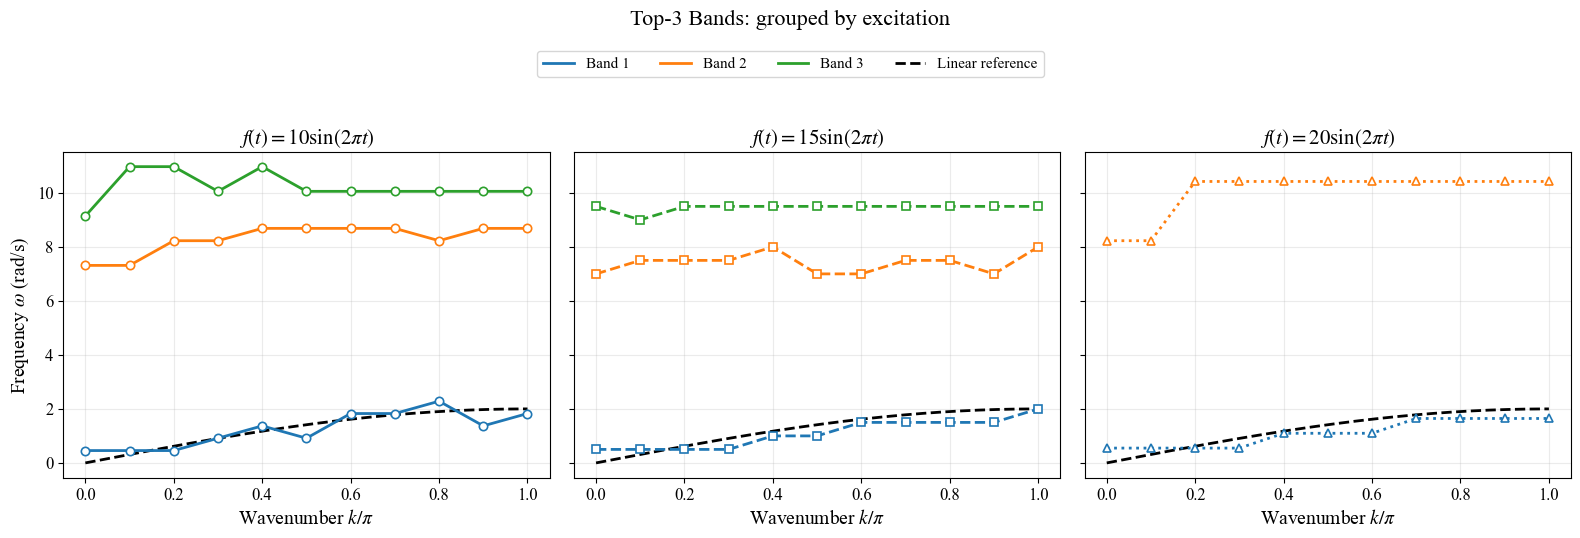

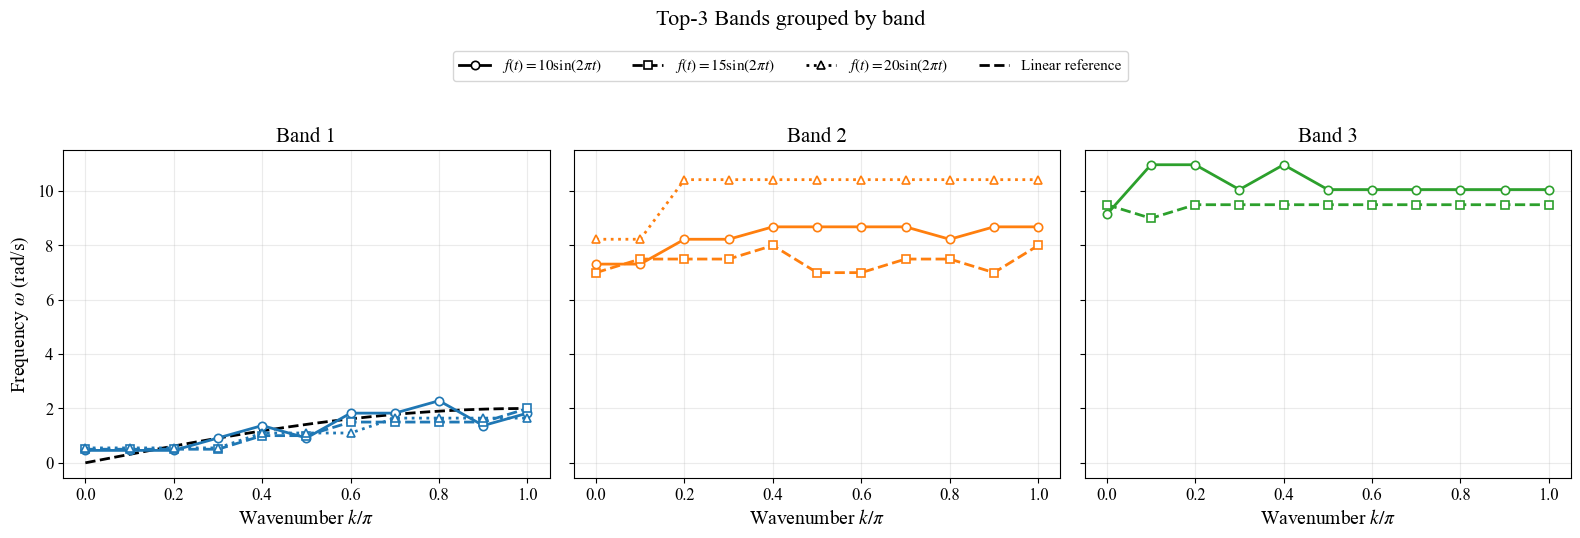

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rcParams

# =============================
# Global font / style settings
# =============================
rcParams['font.family'] = 'Times New Roman'
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.size'] = 13
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 15
rcParams['legend.fontsize'] = 11
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12

# =============================
# Style definitions
# =============================
band_colors = {
    1: 'tab:blue',
    2: 'tab:orange',
    3: 'tab:green',
}

case_styles = {
    'A10': {'linestyle': '-',  'marker': 'o'},
    'A15': {'linestyle': '--', 'marker': 's'},
    'A20': {'linestyle': ':',  'marker': '^'},
}

default_style = {'linestyle': '-', 'marker': 'o'}
case_order = ['A10', 'A15', 'A20']
band_order = [1, 2, 3]

def get_case(label):
    if 'A10' in label:
        return 'A10'
    elif 'A15' in label:
        return 'A15'
    elif 'A20' in label:
        return 'A20'
    else:
        return 'Unknown'

# Optional: nicer case labels for legends/titles
case_label_map = {
    'A10': r'$f(t)=10\sin(2\pi t)$',
    'A15': r'$f(t)=15\sin(2\pi t)$',
    'A20': r'$f(t)=20\sin(2\pi t)$',
}

# =============================
# FIGURE 1:
# one subplot for each excitation
# each subplot contains all bands
# =============================
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

for ax, case in zip(axes1, case_order):
    style = case_styles[case]

    for r in results:
        this_case = get_case(r['label'])
        if this_case != case:
            continue

        for b, omega_b in enumerate(r['bands'], start=1):
            valid = np.isfinite(omega_b)
            if not np.any(valid):
                continue

            ax.plot(
                r['k'][valid] / np.pi,
                omega_b[valid],
                color=band_colors.get(b, 'k'),
                linestyle=style['linestyle'],
                marker=style['marker'],
                linewidth=2,
                markersize=6,
                markerfacecolor='white',
                markeredgewidth=1.2,
                markevery=1,
                zorder=3
            )

    # linear reference
    k_line = np.linspace(0, np.pi, 300)
    ax.plot(
        k_line / np.pi,
        linear_dispersion(k_line, k_coupling, mx),
        color='k',
        linestyle='--',
        linewidth=2,
        zorder=2
    )

    ax.set_title(case_label_map[case])
    ax.set_xlabel(r'Wavenumber $k/\pi$')
    ax.grid(alpha=0.25)

axes1[0].set_ylabel(r'Frequency $\omega$ (rad/s)')

# common legend for bands + reference
handles_fig1 = [
    Line2D([0], [0], color=band_colors[1], lw=2, label='Band 1'),
    Line2D([0], [0], color=band_colors[2], lw=2, label='Band 2'),
    Line2D([0], [0], color=band_colors[3], lw=2, label='Band 3'),
    Line2D([0], [0], color='k', lw=2, linestyle='--', label='Linear reference')
]

fig1.legend(
    handles=handles_fig1,
    loc='upper center',
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 1.05)
)

fig1.suptitle('Top-3 Bands: grouped by excitation', y=1.12, fontsize=16)
fig1.tight_layout()
plt.show()

fig1.savefig(
    'bands_by_excitation.png',
    dpi=300,
    bbox_inches='tight'
)

fig1.savefig(
    'bands_by_excitation.pdf',
    bbox_inches='tight'
)

# =============================
# FIGURE 2:
# one subplot for each band
# each subplot contains all excitations
# =============================
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

for ax, b in zip(axes2, band_order):
    for r in results:
        case = get_case(r['label'])
        style = case_styles.get(case, default_style)

        # Skip if this excitation does not have this band
        if len(r['bands']) < b:
            continue

        omega_b = r['bands'][b - 1]
        valid = np.isfinite(omega_b)
        if not np.any(valid):
            continue

        ax.plot(
            r['k'][valid] / np.pi,
            omega_b[valid],
            color=band_colors[b],
            linestyle=style['linestyle'],
            marker=style['marker'],
            linewidth=2,
            markersize=6,
            markerfacecolor='white',
            markeredgewidth=1.2,
            markevery=1,
            zorder=3
        )

    if b == 1:
        k_line = np.linspace(0, np.pi, 300)
        ax.plot(
            k_line / np.pi,
            linear_dispersion(k_line, k_coupling, mx),
            color='k',
            linestyle='--',
            linewidth=2,
            zorder=2
        )

    ax.set_title(f'Band {b}')
    ax.set_xlabel(r'Wavenumber $k/\pi$')
    ax.grid(alpha=0.25)

axes2[0].set_ylabel(r'Frequency $\omega$ (rad/s)')

handles_fig2 = [
    Line2D([0], [0], color='k', lw=2,
           linestyle=case_styles['A10']['linestyle'],
           marker=case_styles['A10']['marker'],
           markersize=6, markerfacecolor='white', markeredgewidth=1.2,
           label=r'$f(t)=10\sin(2\pi t)$'),
    Line2D([0], [0], color='k', lw=2,
           linestyle=case_styles['A15']['linestyle'],
           marker=case_styles['A15']['marker'],
           markersize=6, markerfacecolor='white', markeredgewidth=1.2,
           label=r'$f(t)=15\sin(2\pi t)$'),
    Line2D([0], [0], color='k', lw=2,
           linestyle=case_styles['A20']['linestyle'],
           marker=case_styles['A20']['marker'],
           markersize=6, markerfacecolor='white', markeredgewidth=1.2,
           label=r'$f(t)=20\sin(2\pi t)$'),
    Line2D([0], [0], color='k', lw=2, linestyle='--', label='Linear reference')
]

fig2.legend(handles=handles_fig2, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05))
fig2.suptitle('Top-3 Bands grouped by band', y=1.12, fontsize=16)
fig2.tight_layout()
plt.show()

fig2.savefig(
    'bands_by_band.png',
    dpi=300,
    bbox_inches='tight'
)

fig2.savefig(
    'bands_by_band.pdf',
    bbox_inches='tight'
)